# **교육 도메인 실전 프로젝트 시작**
- ### 조 이름: HoHo
- ### 조원 :
    - #### 조은솔(조장)
    - #### 유희상
    - #### 전재민
    - #### 김도연
    - #### 정의현
- ### 데이터: Online Course Student Engagement Metrics
    - 링크: https://www.kaggle.com/datasets/thedevastator/online-course-student-engagement-metrics


# **모듈 불러오기 및 기본 설정**

In [138]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import numpy as np
import platform

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

# 출력 짤림 방지
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# **원본 데이터 불러오기 및 결측치 탐색**

In [139]:
# 데이터 불러오기
df = pd.read_csv('./data/Courses.csv', parse_dates=['start_time_DI', 'last_event_DI'])
df.head()

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
0,0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,2013-11-17,NaN,9.0,NaN,NaN,0,NaN,1.0
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaT,NaN,9.0,NaN,1.0,0,NaN,1.0
2,2,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2013-02-08,2013-11-17,NaN,16.0,NaN,NaN,0,NaN,1.0
3,3,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-09-17,NaT,NaN,16.0,NaN,NaN,0,NaN,1.0
4,4,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,NaT,NaN,16.0,NaN,NaN,0,NaN,1.0


In [140]:
# 원본데이터 결측치 개수, 비율
display(pd.DataFrame({
    'sum': df.isna().sum(),
    'ratio': df.isna().mean() * 100
}).sort_values('ratio', ascending=False).reset_index())

,index,sum,ratio
0,roles,641138,100.000000
1,incomplete_flag,540977,84.377622
2,nplay_video,457530,71.362172
3,nchapters,258753,40.358394
4,nevents,199151,31.062111
5,last_event_DI,178954,27.911932
6,ndays_act,162743,25.383459
7,LoE_DI,106008,16.534350
8,YoB,96605,15.067739
9,gender,86806,13.539363


# 전처리 시작
- 전처리용 데이터 셋 생성
- 컬럼명 소문자로 변환
- 중복행 확인
- 컬럼 1차 제거
    - >index: 인덱스 컬럼
    - >roles: 모든 행이 결측으로 이루어진 컬럼
- 데이터 형변환
- 1차 파생컬럼 생성
    -  `age`: 나이
        -  `age_segment`: 연령대 (`age`컬럼 활용)
    -  `step`: 사용자별 마지막 퍼널 단계
    -  `missing_flag` : 결측 패턴 유지를 위한 플래그
        -  `nchapters_flag` : nchapter의 결측 패턴을 유지
        -  `ndays_act_flag` : ndays_act의 결측 패턴을 유지
        -  `nplay_video_flag` : nplay_video의 결측 패턴을 유지
        -  `last_event_di_flag` : last_event_di의 결측 패턴을 유지
        -  `personal_information_flag` : 개인정보의 결측 패턴을 유지
        -  `grade_flag` : 성적의 결측 패턴을 유지
    - `duration` : 강좌 내 활동 지속기간
- 행 제거
    - 논리 오류 위주의 행 제거작업 수행

In [141]:
# 전처리용 데이터 셋 생성
pre = df.copy()

In [142]:
# 컬럼명 소문자로 변환
pre.columns = pre.columns.str.lower()

In [143]:
# 중복행 확인
pre.duplicated().sum()

np.int64(0)

In [144]:
# 의미없는 컬럼 1차 제거
pre = pre.drop(columns=['index', 'roles'])

In [145]:
#데이터 형변환
# grade 숫자형으로 변환
pre['grade'] = pd.to_numeric(pre['grade'], errors='coerce')

In [146]:
# 파생컬럼 생성

# 학생들의 나이(age) & (age_segment)
pre['age'] = pre['start_time_di'].dt.year - pre['yob']

pre['age_segment'] = np.select(
    [
        pre['age'].isna(),
        pre['age'] >= 60,
        pre['age'] >= 50,
        pre['age'] >= 40,
        pre['age'] >= 30,
        pre['age'] >= 20,
    ],
    [
        'unknown',
        '60s+',
        '50s',
        '40s',
        '30s',
        '20s',
    ],
    default='under 20'
)

# 퍼널 단계 컬럼(step): 각 학생 별 진행 단계
pre['step'] = np.select(
    [
        pre['certified'] ==1,
        pre['explored'] == 1,
        pre['viewed'] == 1,
        pre['registered'] == 1,
    ],
    [
        'c',
        'e',
        'v',
        'r'
    ],
    default='None'
)

# Missing Flag 컬럼 생성
missing_col = [
    'nchapters', 
    'nevents',  
    'nplay_video', 
    'last_event_di', 
    'age',
    'grade']

for col in missing_col:
    pre[f'{col}_flag'] = pre[col].isna().astype(int)

pre.rename(columns={'age_flag':'personal_information_flag'}, inplace=True)

# 학습 기간 (duration) 컬럼 생성 (같은 날일 경우 1)
pre['duration'] = ((pre['last_event_di'] - pre['start_time_di'])).dt.days.astype(int, errors='ignore') + 1



In [147]:
# 행제거
print('행 제거 작업 시작 전:')
print(pre.shape)

# 퍼널 논리적 오류 행 제거
funnel_mask1 = (pre['viewed'] == 0) & (pre['explored'] == 1)
funnel_mask2 = (pre['explored'] == 0) & (pre['certified'] == 1)
pre = pre[~funnel_mask1]
pre = pre[~funnel_mask2]

# durration 음수 행 제거
duration_mask = pre['duration'] <= 0
pre = pre[~duration_mask]

# age 13세 미만 행 제거
age_mask = pre['age'] < 13
pre = pre[~age_mask]

# 상시 개방된 강의 제거 
course_mask = (pre['course_id'] =='HarvardX/CS50x/2012') | (pre['course_id'] =='HarvardX/ER22x/2013_Spring') | (pre['course_id'] =='HarvardX/CB22x/2013_Spring')
pre = pre[~course_mask]

# incomplete_flag == 1 제외
pre = pre[pre['incomplete_flag'].isna()]

# 논리적 오류 drop 
rchap_mask = (pre['step']=='r') & ((pre['nchapters'] > 0) | (pre['nplay_video']>0))
pre = pre[~rchap_mask]

# 행동지표가 모두 nan인 행 제외
nan_mask = (pre['nevents'].isna()) & (pre['ndays_act'].isna()) & (pre['last_event_di'].isna())
pre = pre[~nan_mask]

# 코스별 viewed 단계 챕터수 > explored 단계 챕터수 행 제외
e_min = pre[pre['step']=='e'].groupby('course_id')['nchapters'].min().reset_index(name='e_min_chapters')
pre = pd.merge(pre, e_min, how='left', on='course_id')
e_min_mask = (pre['nchapters'] >= pre['e_min_chapters']) & (pre['step']=='v')
pre = pre[~e_min_mask]
pre = pre.drop(columns=['e_min_chapters'])


print('행 제거 작업 후:')
print(pre.shape)


행 제거 작업 시작 전:
(641138, 29)


C:\Users\gmltk\AppData\Local\Temp\ipykernel_172500\2836492611.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pre = pre[~funnel_mask2]


행 제거 작업 후:
(323918, 29)


### **결측치 대체**
- `gender`, `LoE` : 'unknown'으로 대체
- `nchapters` : 
    - registered 단계일 때 0으로 대체
        - 근거: registered 단계에서는 챕터 내 존재하는 영상을 클릭할 수 없음
        > 영상을 클릭했다면 퍼널 viewed 단계로 정의됨(viewed는 챕터를 한 번이라도 클릭한 사람)
    - viewed 단계일 때 퍼널별 중앙값으로 대체
        - 근거: 퍼널별 `nchapters` 수는 수료와 관련이 있음을 증명
- `nplay_video` :
    - `nchapter` 가 0이면 `nplay_video`도 0
        - 근거: 챕터 안에 강의가 들어있음. 챕터 열람이 없었으면 당연히 영상도 볼 수 없음
    - viewed, explored, certified 단계일 때 각 퍼널별 중앙값으로 대체
        - 근거: 퍼널 단계별로 `nplay_video`의 차이가 유의함을 증명함
- `duration` : 활동 지속기간(파생) 결측 0으로 채움


In [148]:
# 결측치 대체

# 성별 결측치(gender) : unknown 대체
pre['gender'] = pre['gender'].fillna('unknown')

# 학력 결측치(LoE_DI) : unknown 대체
pre['loe_di'] = pre['loe_di'].fillna('unknown')

# 탐색한 챕터 수 결측치(nchapters) : registered 단계일 때 0으로 대체
pre.loc[
    (pre['step']=='r') & (pre['nchapters'].isna()),
    'nchapters'
] = 0

# 탐색한 챕터 수 결측치(nchapters) : viewed 단계일 때 2로 대체
v_nchapters_median = pre.loc[
    (pre['step']=='v') & (pre['nchapters'].notna()),
    'nchapters'
].median()

pre.loc[
    (pre['step']=='v') & (pre['nchapters'].isna()),
    'nchapters'
] = v_nchapters_median

# 영상재생횟수(nplay_video) 결측치
pre.loc[
    (pre['nchapters']==0) & (pre['nplay_video'].isna()),
    'nplay_video'
] = 0

# 영상재생횟수 Viewed 단계 결측치 중앙값으로 대체
v_play_median = pre.loc[
    (pre['step']=='v') & (pre['nplay_video'].notna()),
    'nplay_video'
].median()

pre.loc[
    (pre['step']=='v') & (pre['nplay_video'].isna()),
    'nplay_video'
] = v_play_median

# 영상재생횟수 Explored 단계 결측치 중앙값으로 대체
e_play_median = pre.loc[
    (pre['step']=='e') & (pre['nplay_video'].notna()),
    'nplay_video'
].median()

pre.loc[
    (pre['step']=='e') & (pre['nplay_video'].isna()),
    'nplay_video'
] = e_play_median

# 영상재생횟수 Certified 단계 결측치 중앙값으로 대체
c_play_median = pre.loc[
    (pre['step']=='c') & (pre['nplay_video'].notna()),
    'nplay_video'
].median()

pre.loc[
    (pre['step']=='c') & (pre['nplay_video'].isna()),
    'nplay_video'
] = c_play_median

# 활동 지속 기간 (duration)
pre['duration'] = pre['duration'].fillna(0)




In [149]:
# 2차 컬럼 drop
pre = pre.drop(columns=['yob', 'incomplete_flag'])

## **2차 파생컬럼 생성**
- 학습참여점수(`engagement_score`)
    - 효과크기 비율로 가중치를 구해 학습참여점수를 구함
    - 로그변환으로 이상치의 영향을 줄이고, 스케일링을 통해 값의 범위를 조정함
    - 0점 ~ 100점
- 총챕터 수(`course_max_chapters`)
    - 코스별 가장 챕터를 많이 탐색한 학생의 챕터 수
    - 완전한 총 챕터 수라고는 할 수 없으나, 가지고 있는 데이터 중 총 챕터수에 가장 근사한 값을 사용하여 총 챕터수라는 개념으로 사용함
- 진도율(`chapter_progress_pct`)
    - 탐색한 챕터수 / 총 챕터수
    - 0~1 사이의 값
- 학습 몰입도(`learning_engagement`)
    - 학습참여점수와 진도율을 곱하여 얼마나 성실하게 많은 학습에 참여했는지를 계산
    - 로그변환으로 이상치 영향 줄이고 스케일링으로 값의 범위 제한
    - 0~1사이의 값
- 이탈 위험군 Flag(`risk_flag`)
    - 접속일 수가 낮거나, 진도율 절반 이하면서 동영상 재생 없는 사람
    - 이진 플래그

In [150]:
# 2차 파생컬럼 생성

# 학습 참여 점수 (가중치 효과크기 비율로 구함)
weight = {
    'nplay_video': np.float64(0.5243159880047661),
    'ndays_act': np.float64(0.40991294689005575),
    'nforum_posts': np.float64(0.06577106510517815)
    }

pre['engagement_score'] = (
    pre['ndays_act'] * weight['ndays_act'] +
    pre['nplay_video'] * weight['nplay_video'] +
    pre['nforum_posts'] * weight['nforum_posts']
)
log_score = np.log1p(pre['engagement_score'])
pre['engagement_score'] = (log_score - log_score.min()) / (log_score.max() - log_score.min()) * 100

# 코스별 가장 많이 탐색한 학생의 챕터 수
course_max = (
    pre[pre['step'].isin(['e', 'c'])]
    .groupby('course_id')['nchapters']
    .max()
)
pre['course_max_chapters'] = pre['course_id'].map(course_max)

# 진도율 
pre['chapter_progress_pct'] = pre['nchapters'] / pre['course_max_chapters']

# 학습 몰입도
pre['learning_engagement'] = pre['engagement_score'] * pre['chapter_progress_pct']

log_le = np.log1p(pre['learning_engagement'])
pre['learning_engagement'] = (log_le - log_le.min()) / (log_le.max() - log_le.min()) # 스케일링 작업

# 이탈 위험군 Flag
pre['risk_flag'] = (
    (pre['ndays_act'] < 8) | # 접속일수 일주일 미만
    ((pre['chapter_progress_pct'] <= 0.5) & (pre['nplay_video'] == 0)) # 진도율 절반 이하, 강의재생 없음
).astype(int)

# **강의별 공식 일정 데이터 병합**
- ### 내용:
    - course_title: 강의명
    - registration_open: 강의 등록 가능날짜
    - course_launch: 강의 공식 시작일
    - course_wrap: 강의 공식 종료일

In [151]:
# 강의별 공식 일정 테이블 생성 & merge

# 1. course_id별 공식 일정 매핑표
schedule_map = {
        # HarvardX
        'HarvardX/PH207x/2012_Fall': {
                'course_title': 'Health in Numbers: Quantitative Methods in Clinical & Public Health Research',
                'registration_open': '2012-07-24',
                'course_launch': '2012-10-15',
                'course_wrap': '2013-01-30'
        },
        'HarvardX/CS50x/2012': {
                'course_title': 'Introduction to Computer Science I',
                'registration_open': '2012-07-24',
                'course_launch': '2012-10-15',
                        'course_wrap': '2013-04-15'
                },
                'HarvardX/HLS1x/2013_Spring': {
                        'course_title': 'Copyright',
                        'registration_open': '2012-12-19',
                        'course_launch': '2013-01-28',
                        'course_wrap': '2013-07-03'
                },
                'HarvardX/ER22x/2013_Spring': {
                        'course_title': 'Justice',
                        'registration_open': '2012-12-19',
                        'course_launch': '2013-03-02',
                        'course_wrap': '2013-07-26'
                },
                'HarvardX/CB22x/2013_Spring': {
                        'course_title': 'The Ancient Greek Hero',
                        'registration_open': '2012-12-19',
                        'course_launch': '2013-03-13',
                        'course_wrap': '2013-08-26'
                },
                'HarvardX/PH278x/2013_Spring': {
                        'course_title': 'Human Health and Global Environmental Change',
                        'registration_open': '2012-12-19',
                        'course_launch': '2013-05-15',
                        'course_wrap': '2013-07-25'
                },

                # MITx
                'MITx/6.002x/2012_Fall': {
                        'course_title': 'Circuits and Electronics - Fall',
                        'registration_open': '2012-07-24',
                        'course_launch': '2012-09-05',
                        'course_wrap': '2012-12-25'
                },
                'MITx/6.00x/2012_Fall': {
                        'course_title': 'Introduction to Computer Science and Programming - Fall',
                        'registration_open': '2012-07-24',
                        'course_launch': '2012-09-26',
                        'course_wrap': '2013-01-15'
                },
                'MITx/3.091x/2012_Fall': {
                        'course_title': 'Introduction to Solid State Chemistry - Fall',
                        'registration_open': '2012-07-24',
                        'course_launch': '2012-10-09',
                        'course_wrap': '2013-01-15'
                },
                'MITx/6.00x/2013_Spring': {
                        'course_title': 'Introduction to Computer Science and Programming - Spring',
                        'registration_open': '2012-12-19',
                        'course_launch': '2013-02-04',
                        'course_wrap': '2013-06-04'
                },
                'MITx/3.091x/2013_Spring': {
                        'course_title': 'Introduction to Solid State Chemistry - Spring',
                        'registration_open': '2012-12-20',
                        'course_launch': '2013-02-05',
                        'course_wrap': '2013-06-21'
                },
                'MITx/14.73x/2013_Spring': {
                        'course_title': 'The Challenges of Global Poverty',
                        'registration_open': '2012-12-19',
                        'course_launch': '2013-02-12',
                        'course_wrap': '2013-05-21'
                },
                'MITx/8.02x/2013_Spring': {
                        'course_title': 'Electricity and Magnetism',
                        'registration_open': '2013-01-17',
                        'course_launch': '2013-02-18',
                        'course_wrap': '2013-06-18'
                },
                'MITx/6.002x/2013_Spring': {
                        'course_title': 'Circuits and Electronics - Spring',
                        'registration_open': '2012-12-20',
                        'course_launch': '2013-03-03',
                        'course_wrap': '2013-07-01'
                },
                'MITx/7.00x/2013_Spring': {
                        'course_title': 'Introduction to Biology - The Secret of Life',
                        'registration_open': '2013-01-30',
                        'course_launch': '2013-03-05',
                        'course_wrap': '2013-06-06'
                },
                'MITx/2.01x/2013_Spring': {
                        'course_title': 'Elements of Structures',
                        'registration_open': '2013-02-24',
                        'course_launch': '2013-04-15',
                        'course_wrap': '2013-07-30'
                },
                'MITx/8.MReV/2013_Summer': {
                        'course_title': 'Mechanics ReView',
                        'registration_open': '2013-04-27',
                        'course_launch': '2013-06-01',
                        'course_wrap': '2013-09-15'
                }
}

# 2. dict -> DataFrame 변환
schedule_df = (
        pd.DataFrame(schedule_map)
        .T
        .reset_index()
        .rename(columns={'index': 'course_id'})
)

# 3. 날짜형 변환
date_cols = ['registration_open', 'course_launch', 'course_wrap']
for col in date_cols:
        schedule_df[col] = pd.to_datetime(schedule_df[col])

pre = pd.merge(pre, schedule_df, how='left', on='course_id')

# **통계검정 시작**
- 학습 참여 점수: `Engagement_Score` 가중치 구하기
    - `nplay_video`
    - `ndays_act`
    - `nforum_posts`
    > 각각의 효과크기를 구하고 효과크기의 비율로 가중치를 계산
- 수료 여부와 이탈위험군 Flag가 관계가 있을까?
- 수료를 한 그룹과 안 한 그룹의 학습 몰입도는 차이가 있는가?
- 수료를 한 그룹과 안한 그룹의 진도율은 차이가 있을까?
- 수료를 한 그룹과 안한 그룹의 학습 참여 점수는 차이가 있을까?

<Axes: >

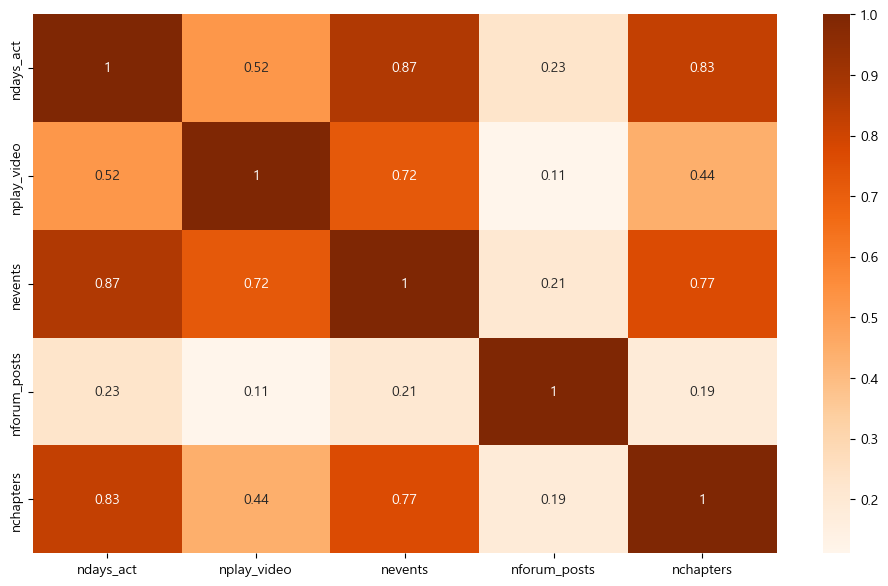

In [152]:
# 사용자 행동지표 별 상관관계 : 다중공선성 확인을 위한 확인과정
pre_corr = pre[['ndays_act', 'nplay_video', 'nevents', 'nforum_posts','nchapters']].corr()
plt.figure(figsize=(12,7))
sns.heatmap(pre_corr, cmap='Oranges', annot=True)

In [153]:
# 다중공선성으로 인해 nevents, nchapters 제거 후 수료여부별 효과크기를 계산을 진행

# nplay_video부터 시작

# 먼저 그룹을 나눔
np_T = pre.loc[
    (pre['certified']==1)
    , 'nplay_video'
] # 수료를 한 그룹의 nplay_video

np_F = pre.loc[
    (pre['certified']==0)
    , 'nplay_video'
] # 수료를 못한 그룹의 nplay_video

print(np_T.shape)
print(np_F.shape)

(13426,)
(310492,)


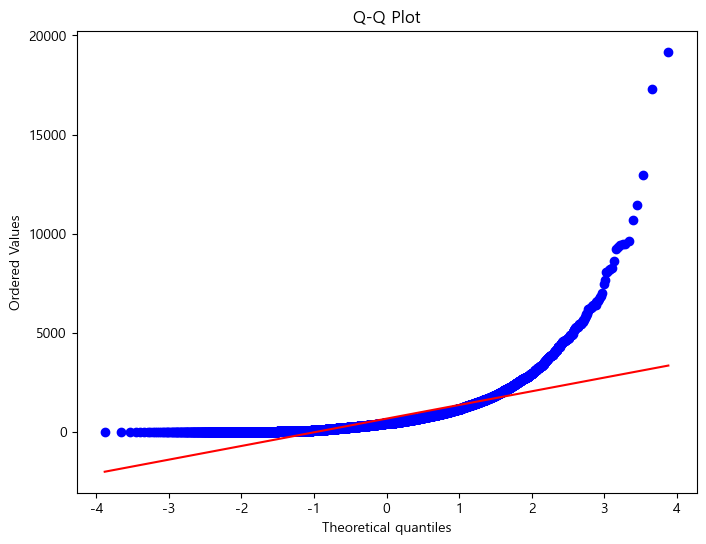

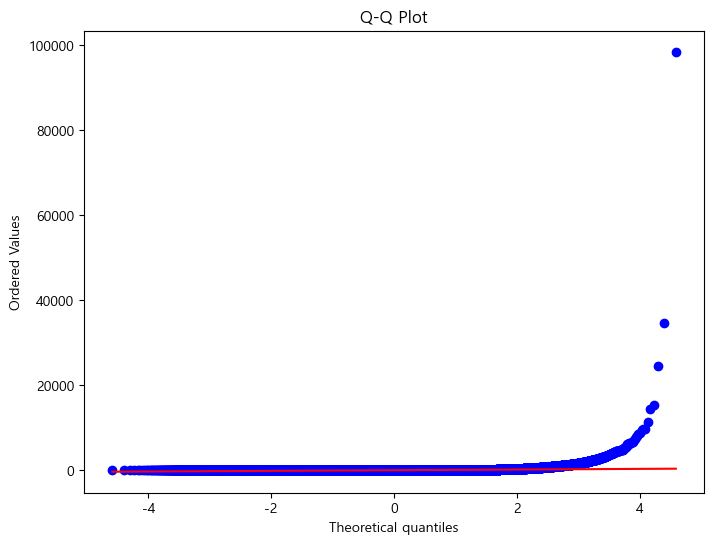

In [154]:
# QQ-Plot 뽑아보기

plt.figure(figsize=(8, 6))
stats.probplot(np_T, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

plt.figure(figsize=(8, 6))
stats.probplot(np_F, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

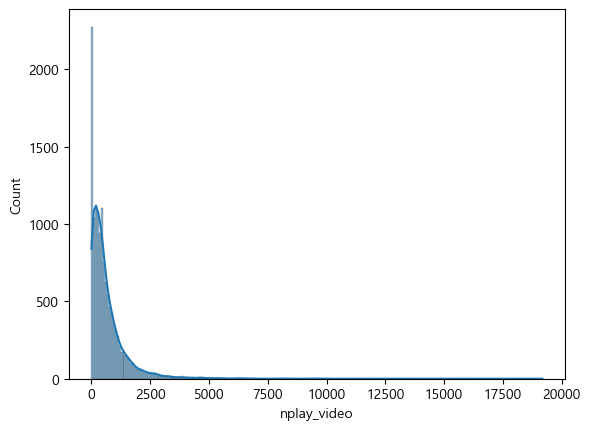

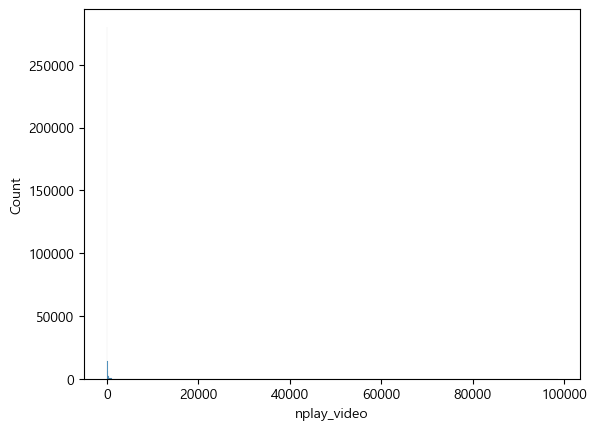

In [155]:
# 히스토그램 그리기
sns.histplot(np_T, kde=True)
plt.show()

sns.histplot(np_F, kde=False)
plt.show()

In [156]:
# 정규성 검정 : 표본 수 차이가 커서 분산에 차이가 커 정규성 기각됨.
# 근데 보통은 표본 수가 크면 정규성이 있다고 가정하고 검정하는 것이 맞음.
# 근데 이번 상황은 롱테일 분포이기 때문에 너무 왜곡되어있다고 판단하고 비모수 검정을 진행함.
def ks_test(group):
    sample_mean = np.mean(group)
    s = np.std(group, ddof=1)

    statsa, ps = stats.kstest(group,'norm', args=(sample_mean, s))
    return ps

p_np_T = ks_test(np_T)
p_np_F = ks_test(np_F)

print(f'{p_np_T:5f}') # 0.000000 # 정규성 기각
print(f'{p_np_F:5f}') # 0.000000 # 정규성 기각


0.000000
0.000000


In [157]:
# 통계검정 (비모수 검정인 mannwhitneyU검정 수행)

stat_U, p_U = stats.mannwhitneyu(np_T, np_F, alternative='two-sided')
print(stat_U, p_U) # 당연히 p < 0.05

3873276294.0 0.0


In [158]:
# RBC 효과크기 검정
def rbc(x, y, stat):
    nx = len(x)
    ny = len(y)
    return ((2 * stat) / (nx * ny))-1

rbc_np = rbc(np_T, np_F, stat_U) 
print(rbc_np) # 0.8582811254676435

0.8582811254676435


In [159]:
# ndays_act 효과크기 계산 시작

# 그룹 분리
na_T = pre.loc[
    (pre['certified']==1)
    , 'ndays_act'
] # 수료를 한 그룹의 nplay_video

na_F = pre.loc[
    (pre['certified']==0)
    , 'nplay_video'
] # 수료를 못한 그룹의 nplay_video

print(na_T.shape)
print(na_F.shape)


(13426,)
(310492,)


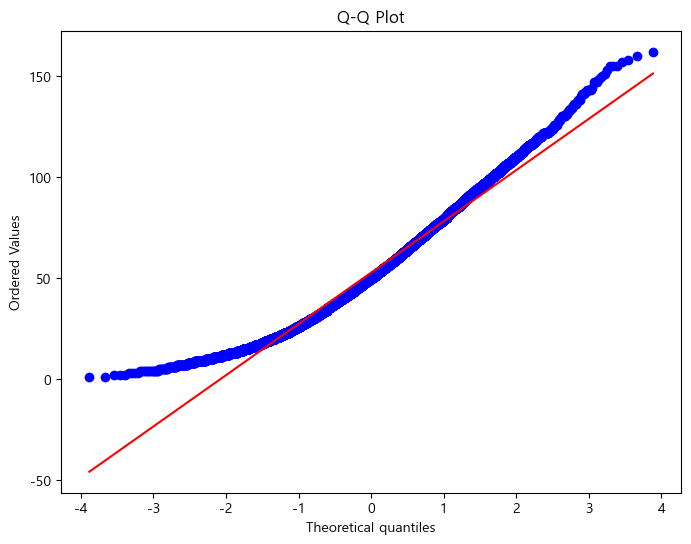

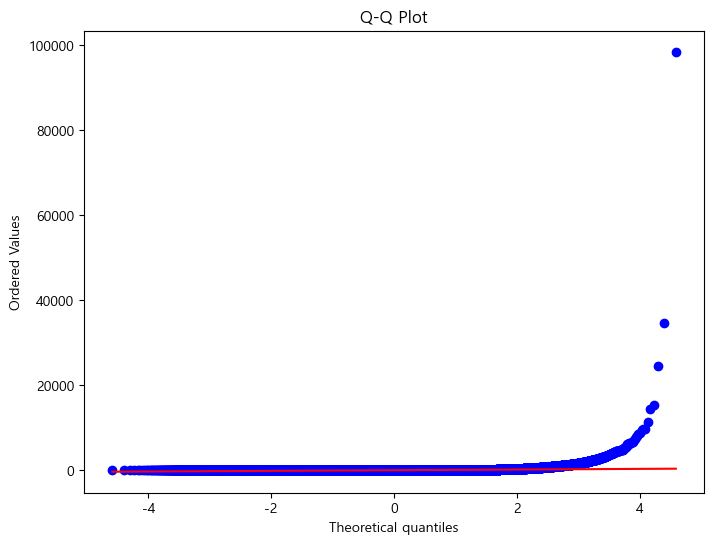

In [160]:
# QQ-Plot 뽑아보기

plt.figure(figsize=(8, 6))
stats.probplot(na_T, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

plt.figure(figsize=(8, 6))
stats.probplot(na_F, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

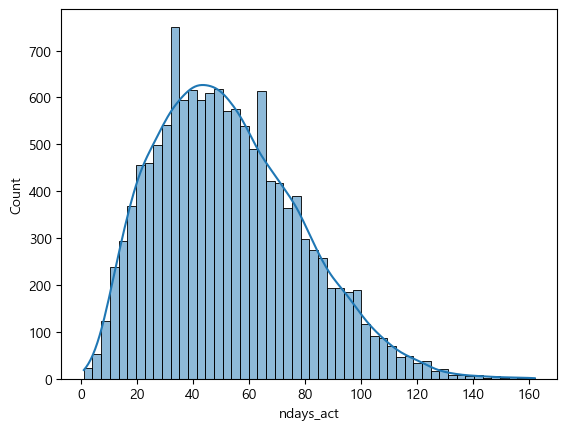

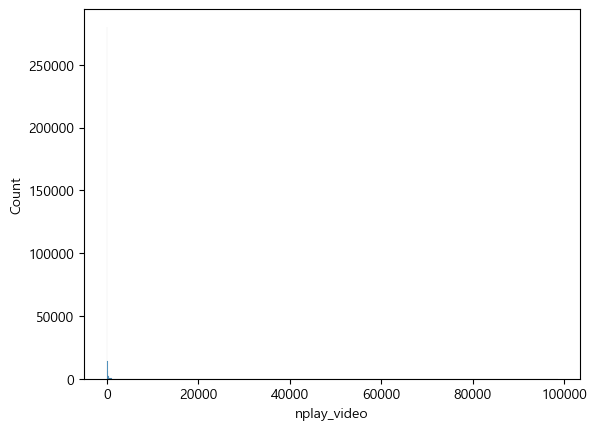

In [161]:
# 히스토그램 그리기
sns.histplot(na_T, kde=True)
plt.show()

sns.histplot(na_F, kde=False)
plt.show()

In [162]:
# 정규성 검정
p_na_T = ks_test(na_T)
p_na_F = ks_test(na_F)

print(f'{p_na_T:5f}') # 0.000000 # 정규성 기각
print(f'{p_na_F:5f}') # 0.000000 # 정규성 기각


0.000000
0.000000


In [163]:
# 통계검정 (비모수 검정인 mannwhitneyU검정 수행)

stat_U, p_U = stats.mannwhitneyu(na_T, na_F, alternative='two-sided')
print(stat_U, p_U) # 당연히 p < 0.05

3482938060.5 0.0


In [164]:
# RBC 효과크기 검정
rbc_na = rbc(na_T, na_F, stat_U) 
print(rbc_na) # 0.6710086158909145

0.6710086158909145


In [165]:
# nforum_posts 통계검정 시작

# 그룹 분리
nf_T = pre.loc[
    (pre['certified']==1)
    , 'nforum_posts'
] # 수료를 한 그룹의 nplay_video

nf_F = pre.loc[
    (pre['certified']==0)
    , 'nforum_posts'
] # 수료를 못한 그룹의 nplay_video

print(nf_T.shape)
print(nf_F.shape)


(13426,)
(310492,)


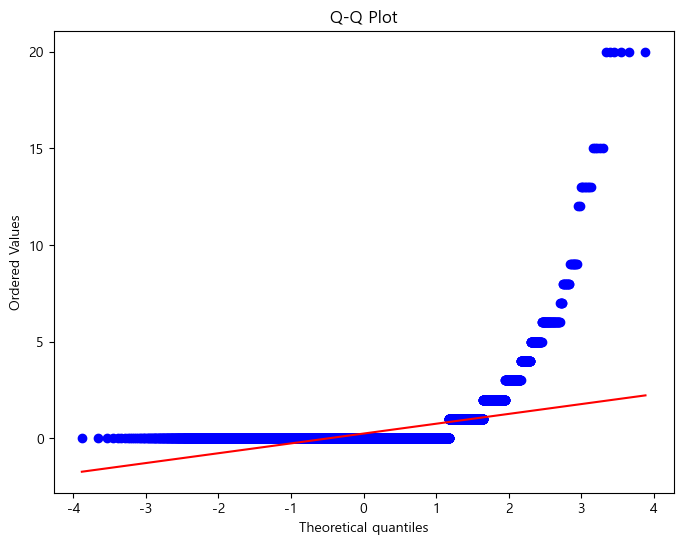

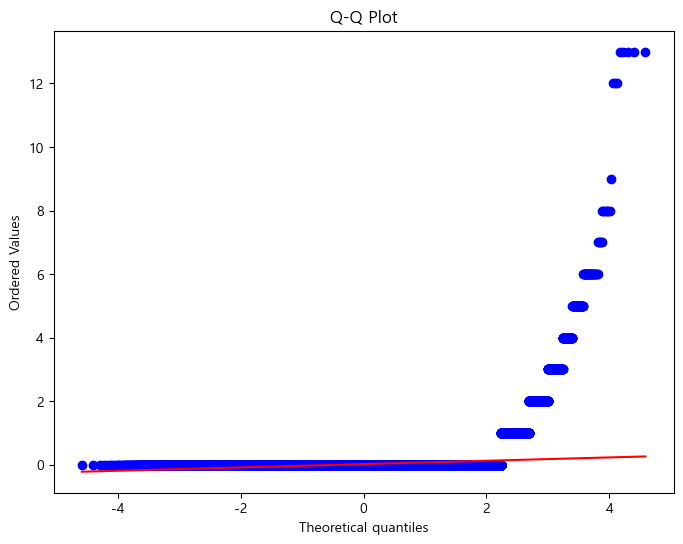

In [166]:
# QQ-Plot 뽑아보기

plt.figure(figsize=(8, 6))
stats.probplot(nf_T, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

plt.figure(figsize=(8, 6))
stats.probplot(nf_F, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

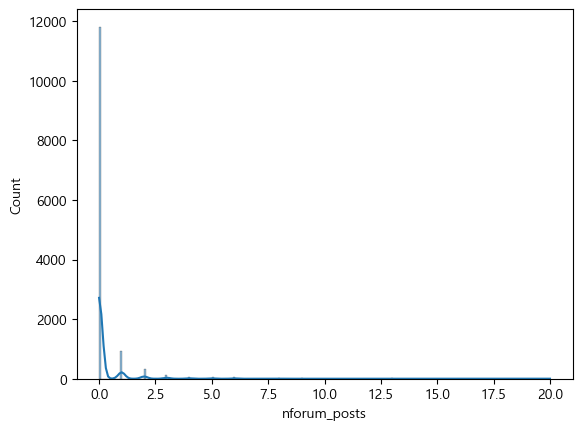

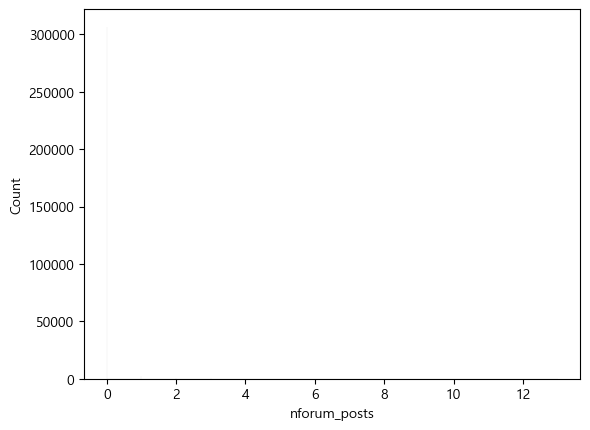

In [167]:
# 히스토그램 그리기
sns.histplot(nf_T, kde=True)
plt.show()

sns.histplot(nf_F, kde=False)
plt.show()

In [168]:
# 정규성 검정 : 표본 수 차이가 커서 당연히 분산에 차이가 크겠지만, 그래도 과정상 진행
p_nf_T = ks_test(nf_T)
p_nf_F = ks_test(nf_F)

print(f'{p_nf_T:5f}') # 0.000000 # 정규성 기각
print(f'{p_nf_F:5f}') # 0.000000 # 정규성 기각


0.000000
0.000000


In [169]:
# 통계검정 (비모수 검정인 mannwhitneyU검정 수행)

stat_U, p_U = stats.mannwhitneyu(nf_T, nf_F, alternative='two-sided')
print(stat_U, p_U) # 당연히 p < 0.05

2308740828.5 0.0


In [170]:
# RBC 효과크기 검정
rbc_nf = rbc(nf_T, nf_F, stat_U)
print(rbc_nf) # 0.10766420455056736

0.10766420455056736


In [171]:
# 가중치 저장
effect_sizes = {
    'nplay_video': rbc_np,
    'ndays_act' : rbc_na,
    'nforum_posts': rbc_nf
}

total = sum(abs(v) for v in effect_sizes.values())

weights ={k: abs(v)/total for k, v in effect_sizes.items()}
weights

{'nplay_video': np.float64(0.5243159880047661),
 'ndays_act': np.float64(0.40991294689005575),
 'nforum_posts': np.float64(0.06577106510517815)}

## 각 퍼널 단계별 nplay_video는 차이가 있는가?

In [172]:
# 검정을 위한 임시테이블 생성 ㅠㅠ
temp=df.copy()

# 학습 기간 (duration) 컬럼 생성 (같은 날일 경우 1)
temp['duration'] = ((temp['last_event_DI'] - temp['start_time_DI'])).dt.days.astype(int, errors='ignore') + 1

temp['step'] = np.select(
    [
        temp['certified'] ==1,
        temp['explored'] == 1,
        temp['viewed'] == 1,
        temp['registered'] == 1,
    ],
    [
        'c',
        'e',
        'v',
        'r'
    ],
    default='None'
)

temp.loc[
    (temp['step']=='r') & (temp['nplay_video'].isna()),
    'nplay_video'
]=0

# 행제거
print('행 제거 작업 시작 전:')
print(temp.shape)

# 퍼널 논리적 오류 행 제거
funnel_mask1 = (temp['viewed'] == 0) & (temp['explored'] == 1)
funnel_mask2 = (temp['explored'] == 0) & (temp['certified'] == 1)
temp = temp[~funnel_mask1]
temp = temp[~funnel_mask2]

# durration 음수 행 제거
duration_mask = temp['duration'] <= 0
temp = temp[~duration_mask]

# 상시 개방된 강의 제거 
course_mask = (temp['course_id'] =='HarvardX/CS50x/2012') | (temp['course_id'] =='HarvardX/ER22x/2013_Spring') | (temp['course_id'] =='HarvardX/CB22x/2013_Spring')
temp = temp[~course_mask]

# incomplete_flag == 1 제외
temp = temp[temp['incomplete_flag'].isna()]

# 논리적 오류 drop 
rchap_mask = (temp['step']=='r') & ((temp['nchapters'] > 0) | (temp['nplay_video']>0))
temp = temp[~rchap_mask]

print('행 제거 작업 후:')
print(temp.shape)

행 제거 작업 시작 전:
(641138, 23)


C:\Users\gmltk\AppData\Local\Temp\ipykernel_172500\2516107589.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  temp = temp[~funnel_mask2]


행 제거 작업 후:
(354392, 23)


In [173]:
# 각 그룹별 nplayvideos 분리

v = temp.loc[
    (temp['registered']== 1) &
    (temp['viewed'] == 1) &
    (temp['explored']==0) &
    (temp['certified']==0) &
    (temp['nplay_video'].notna()),
    'nplay_video']

print(v.shape)

r = temp.loc[
    (temp['registered']== 1) &
    (temp['viewed'] == 0) &
    (temp['explored']==0) &
    (temp['certified']==0) &
    (temp['nplay_video'].notna()),
    'nplay_video']

print(r.shape)

e = temp.loc[
    (temp['registered']== 1) &
    (temp['viewed'] == 1) &
    (temp['explored']==1) &
    (temp['certified']==0) &
    (temp['nplay_video'].notna()),
    'nplay_video']

print(e.shape)

c = temp.loc[
    (temp['registered']== 1) &
    (temp['viewed'] == 1) &
    (temp['explored']==1) &
    (temp['certified']==1) &
    (temp['nplay_video'].notna()),
    'nplay_video']

print(c.shape)

(157317,)
(118980,)
(10638,)
(13137,)


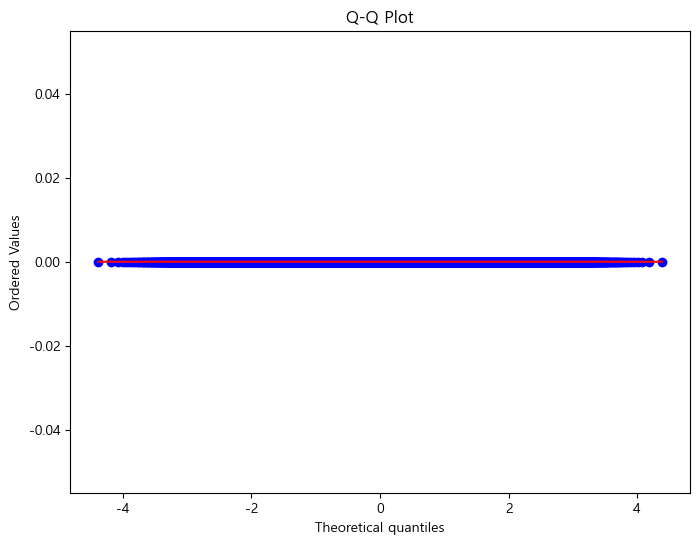

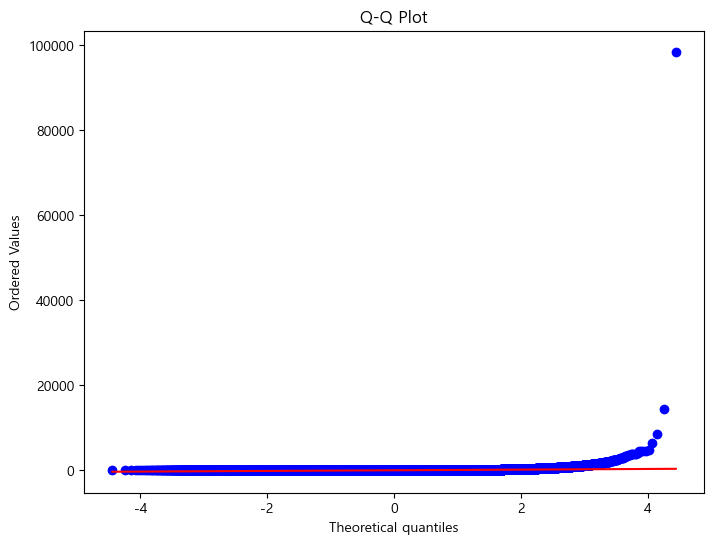

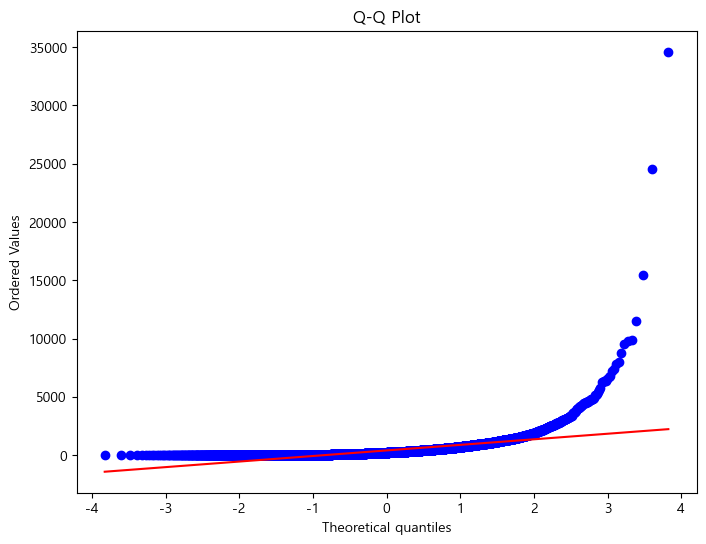

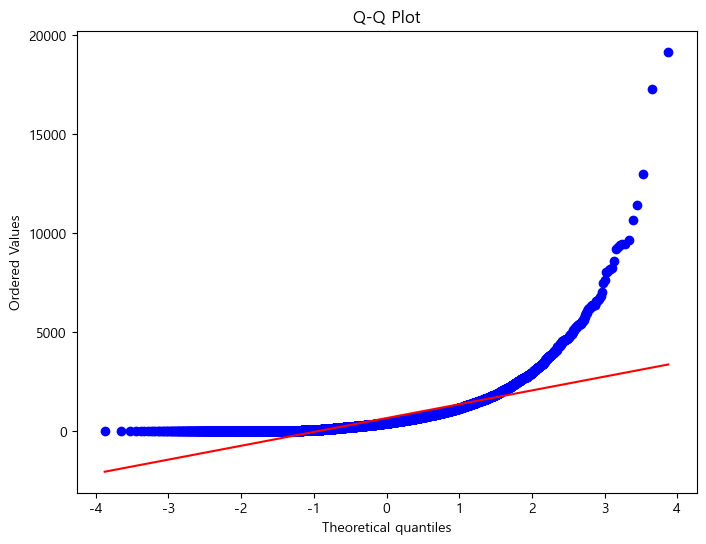

In [174]:
## qqplot

plt.figure(figsize=(8, 6))
stats.probplot(r, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

plt.figure(figsize=(8, 6))
stats.probplot(v, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

plt.figure(figsize=(8, 6))
stats.probplot(e, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

plt.figure(figsize=(8, 6))
stats.probplot(c, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

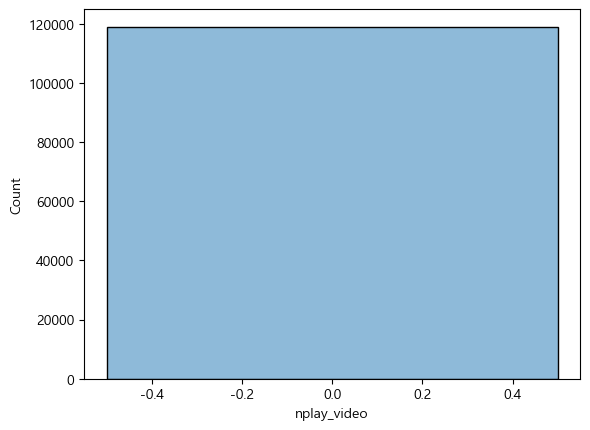

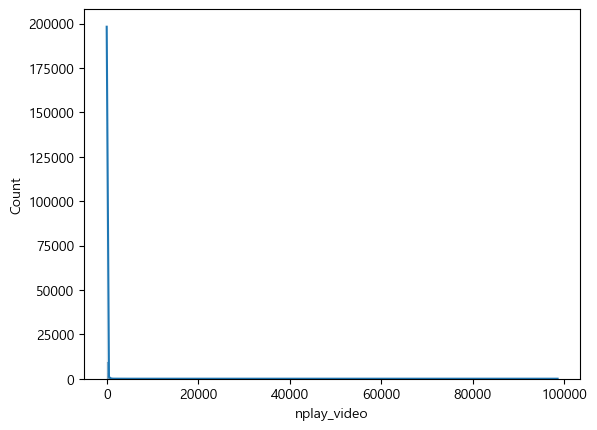

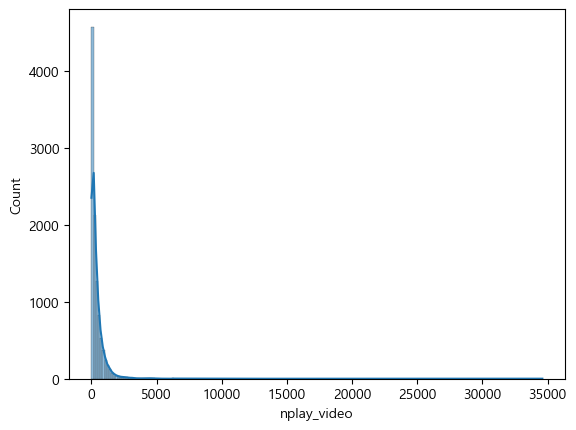

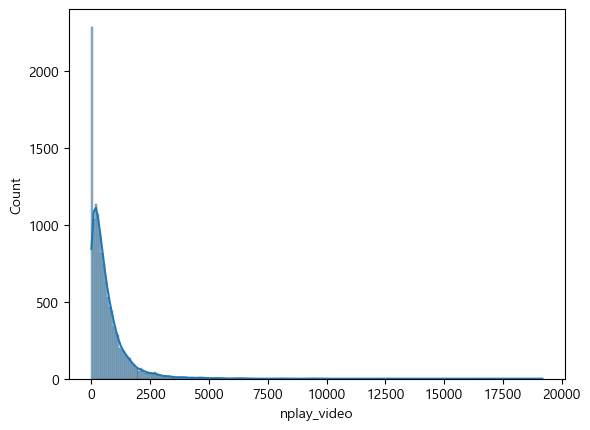

In [175]:
def fff(df):
    sns.histplot(df, kde=True)
    plt.show()

fff(r)
fff(v)
fff(e)
fff(c)

In [176]:
# 정규성 검정
p_r = ks_test(r)
p_v = ks_test(v)
p_e = ks_test(e)
p_c = ks_test(c)
print(p_r)
print(p_v)
print(p_e)
print(p_c)

nan
0.0
0.0
0.0


c:\Users\gmltk\Desktop\스파르타 내일배움\004_projects\projects\HOHO_Project\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2159: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


In [177]:
# MannwhitneyU 검정
stat_rv, p_rv = stats.mannwhitneyu(r, v, alternative='two-sided')
print(stat_rv, p_rv)
stat_ve, p_ve = stats.mannwhitneyu(v, e, alternative='two-sided')
print(stat_ve, p_ve)
stat_ec, p_ec = stats.mannwhitneyu(e, c, alternative='two-sided')
print(stat_ec, p_ec)

0.0 0.0
257546455.5 0.0
51294885.0 3.988908349568165e-273


In [178]:
# RBC 효과크기 검정
print(rbc(r,v,stat_rv))
print(rbc(v,e,stat_ve))
print(rbc(e,c,stat_ec))

-1.0
-0.6922132420748991
-0.26591243024775


## 수료 여부 별 이탈 위험군 Flag의 차이가 있는가?


<Axes: >

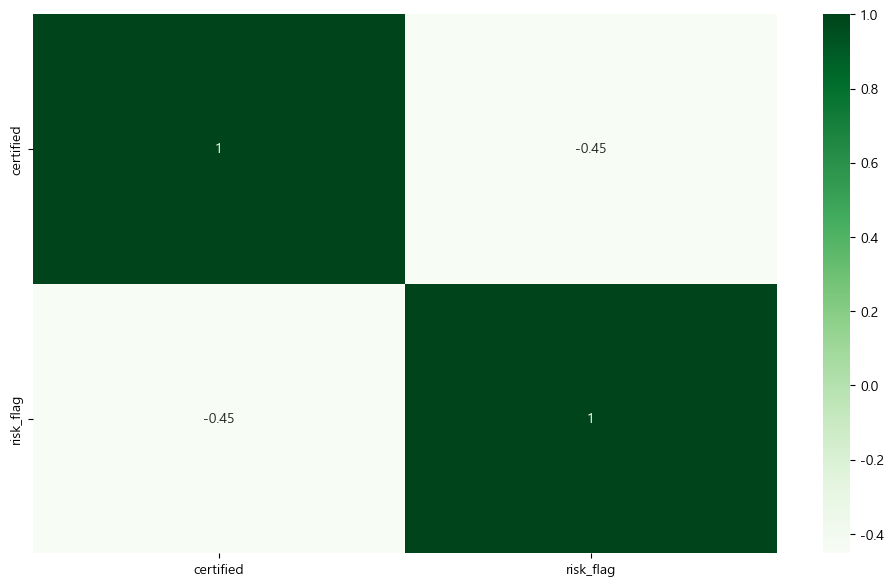

In [179]:
# 이탈 위험 학생 
# 카이제곱 검정 필요할 듯

# 상관관계 먼저
dropout_risk_corr = pre[['certified', 'risk_flag']].corr()
plt.figure(figsize=(12,7))
sns.heatmap(dropout_risk_corr, cmap='Greens', annot=True)

In [180]:
# 카이제곱 검정 (crammer's V까지 구하기)

def CramerV(df, col1, col2):
    temp = df.copy()
    ct_test= pd.crosstab(temp[col1], temp[col2])
    chi2, p_value, dof, expected = stats.chi2_contingency(ct_test)
    n = ct_test.sum().sum()
    r, c = ct_test.shape
    df_star = min(r - 1, c - 1)
    cramers_v = np.sqrt(chi2 / (n * df_star))
    return [cramers_v, chi2, p_value, dof, expected, ct_test]


# 효과크기 검정, 카이제곱 통계량
print(f'certified와 risk_flag 의 통계량, 효과크기 검정')
print(f"카이제곱 통계량: {CramerV(pre, 'certified', 'risk_flag')[1]:.2f}, ")
print(f"자유도:         {CramerV(pre, 'certified', 'risk_flag')[3]}, ")
print(f"p-value:        {CramerV(pre, 'certified', 'risk_flag')[2]:.4f}, " )
print(f"Cramér's V:     {CramerV(pre, 'certified', 'risk_flag')[0]}, ")
print(f"기대빈도: {CramerV(pre, 'certified', 'risk_flag')[4]}, ")
print('\n','='*50,'\n')

certified와 risk_flag 의 통계량, 효과크기 검정
카이제곱 통계량: 66258.47, 
자유도:         1, 
p-value:        0.0000, 
Cramér's V:     0.45227561815926526, 
기대빈도: [[ 53566.7188486 256925.2811514]
 [  2316.2811514  11109.7188486]], 




risk_flag,0,1
certified,,
0,-47.673210,21.767998
1,229.258938,-104.681607


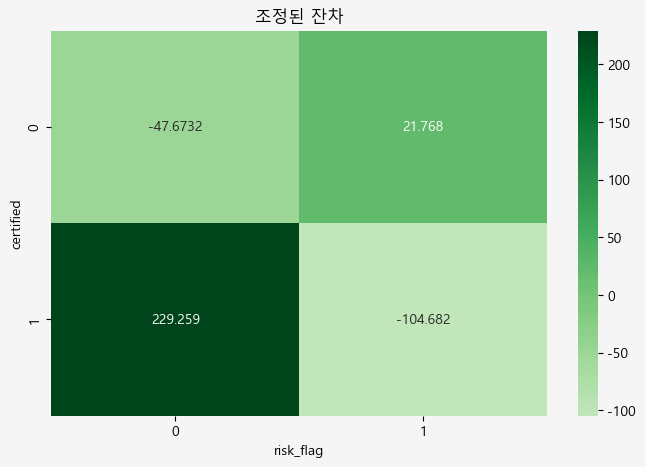

In [181]:
# 조정된 잔차분석
drop_cram = CramerV(pre, 'certified', 'risk_flag')
residuals = ((drop_cram[5] - drop_cram[4]) / np.sqrt(drop_cram[4]))
residuals = residuals.sort_index(ascending=True)
display(residuals)

# 히트맵 시각화
plt.figure(figsize=(8, 5), facecolor='whitesmoke')
sns.heatmap(residuals, annot=True, center=0, cmap='Greens', fmt='g')
plt.title("조정된 잔차")
plt.show()

In [182]:
# Odds Ratio : 1에 가까울 수록 성능이 좋음!

ct_table= pd.crosstab(pre['risk_flag'], pre['certified'])
a = ct_table.loc[0, 1]  # dropout_risk=0, certified=1
b = ct_table.loc[0, 0]  # dropout_risk=0, certified=0
c = ct_table.loc[1, 1]  # dropout_risk=1, certified=1
d = ct_table.loc[1, 0]  # dropout_risk=1, certified=0

or_value = (c * b) / (d * a)
display(ct_table)
print(f'{or_value:.5f}')

certified,0,1
risk_flag,,
0,42533,13350
1,267959,76


0.00090


### 수료를 한 그룹과 안 한 그룹의 학습 몰입도는 차이가 있는가?


<Axes: >

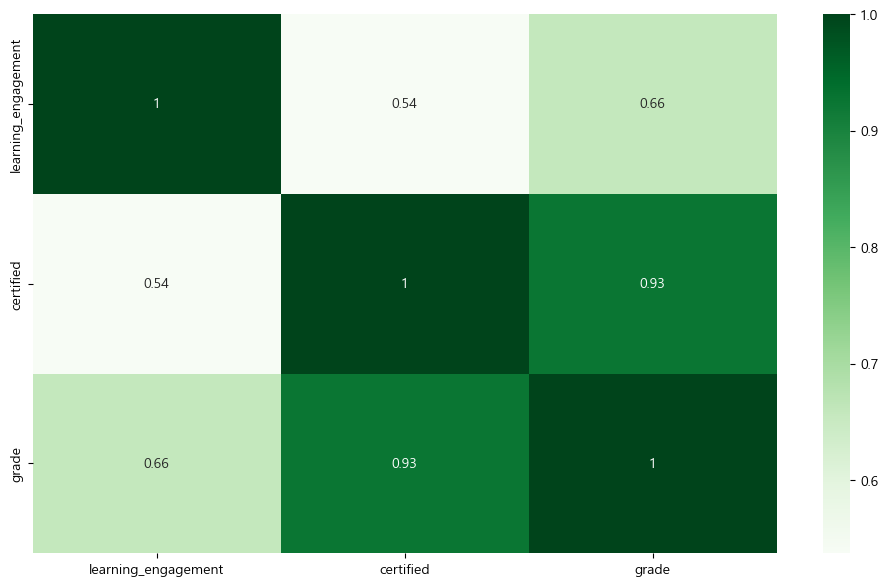

In [183]:
# learning_engagement 과 성과지표 간 상관관계
duration_corr = pre[['learning_engagement', 'certified', 'grade']].corr()
plt.figure(figsize=(12,7))
sns.heatmap(duration_corr, annot=True, cmap='Greens')

In [184]:
# 수료 여부별 학습 몰입도 비교
# 데이터 분리

le_T = pre.loc[
    (pre['certified']==1),
    'learning_engagement'
    ]

le_F = pre.loc[
    (pre['certified']==0,
    'learning_engagement')
]

print(len(le_T))# 13426
print(len(le_F))# 310492
#불균형데이터

13426
310492


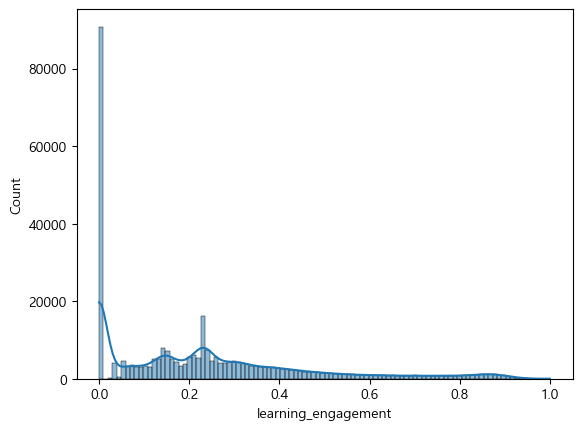

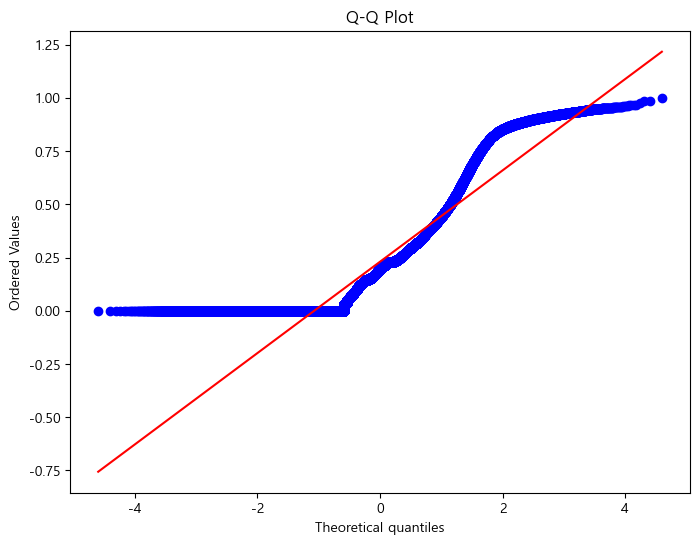

In [185]:
# 전체 분포 QQplot and 분포확인

# 히스토그램 그리기
sns.histplot(pre['learning_engagement'], kde=True)
plt.show()

# QQ-Plot 뽑아보기

plt.figure(figsize=(8, 6))
stats.probplot(pre['learning_engagement'], dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

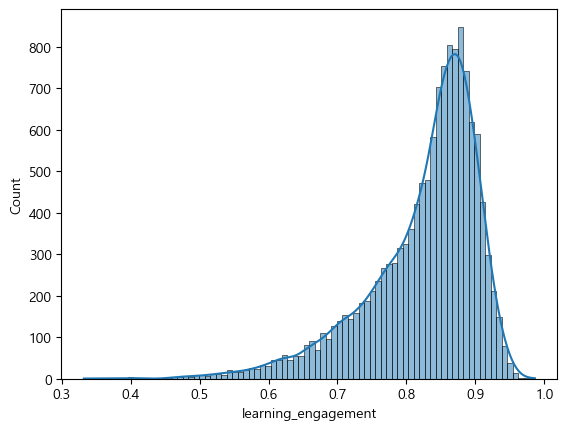

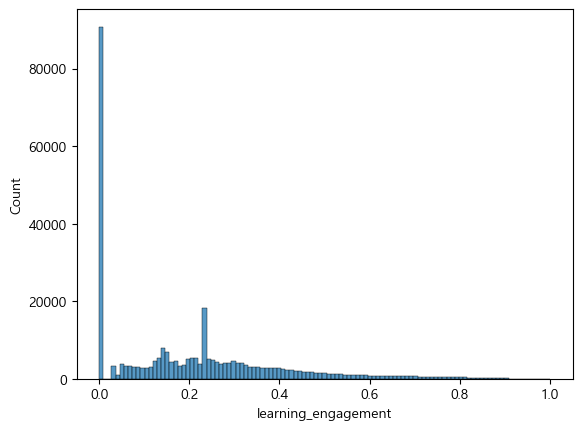

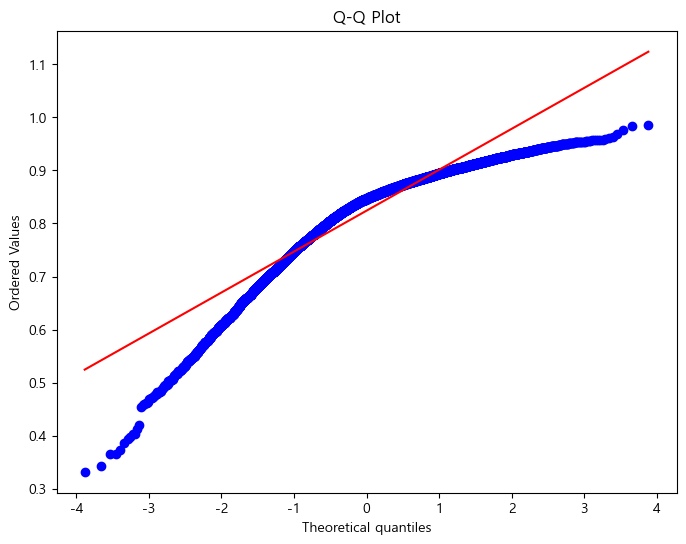

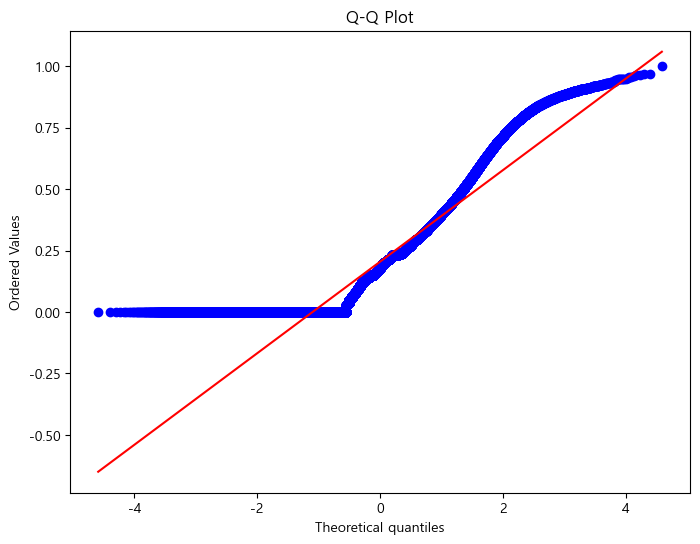

In [186]:
# QQplot and 분포확인

# 히스토그램 그리기
sns.histplot(le_T, kde=True)
plt.show()

sns.histplot(le_F, kde=False)
plt.show()

# QQ-Plot 뽑아보기

plt.figure(figsize=(8, 6))
stats.probplot(le_T, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

plt.figure(figsize=(8, 6))
stats.probplot(le_F, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [187]:
# 정규성 검정 
p_le_T = ks_test(le_T)
p_le_F = ks_test(le_F)

print(f'{p_le_T:5f}') # 0.000000 # 정규성 기각
print(f'{p_le_F:5f}') # 0.000000 # 정규성 기각


0.000000
0.000000


In [188]:
# 통계검정 (비모수 검정인 mannwhitneyU검정 수행)
stat_U, p_U = stats.mannwhitneyu(le_T, le_F, alternative='two-sided')
print(stat_U, p_U) # 당연히 p < 0.05

4130524674.5 0.0


In [189]:
# RBC 효과크기 검정
rbc_le = rbc(le_T, le_F, stat_U)
print(rbc_le) # 0.9817011383339573

0.9817011383339573


### 수료를 한 그룹과 안한 그룹의 진도율은 차이가 있을까?

<Axes: >

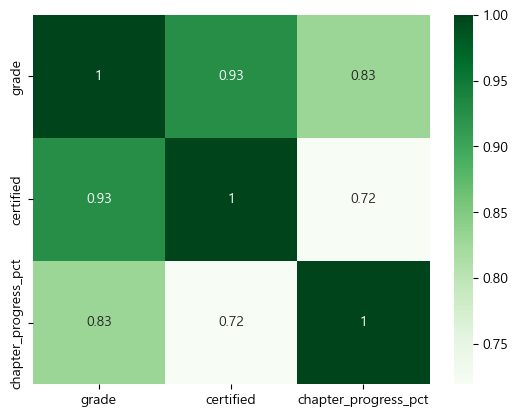

In [190]:
# 진도율 검정 시작!'chapter_progress_pct'
# 일단 상관관계 먼저

total_chapter_corr = pre[['grade', 'certified', 'chapter_progress_pct']].corr()
sns.heatmap(total_chapter_corr, annot=True, cmap='Greens')

In [191]:
# 수료 여부별 학습 몰입도 비교
# 데이터 분리

cp_T = pre.loc[
    (pre['certified']==1),
    'chapter_progress_pct'
    ]

cp_F = pre.loc[
    (pre['certified']==0,
    'chapter_progress_pct')
]

print(len(cp_T))# 13426
print(len(cp_F))# 310492


13426
310492


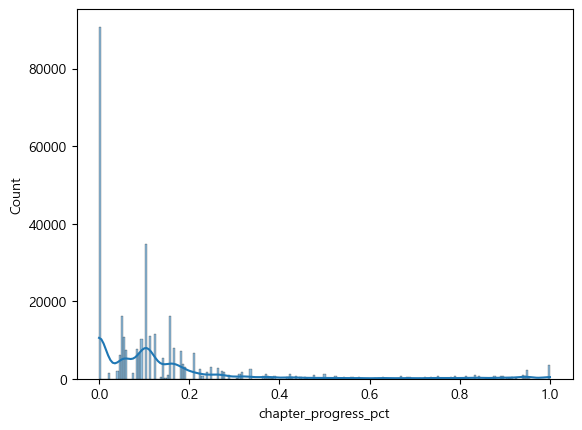

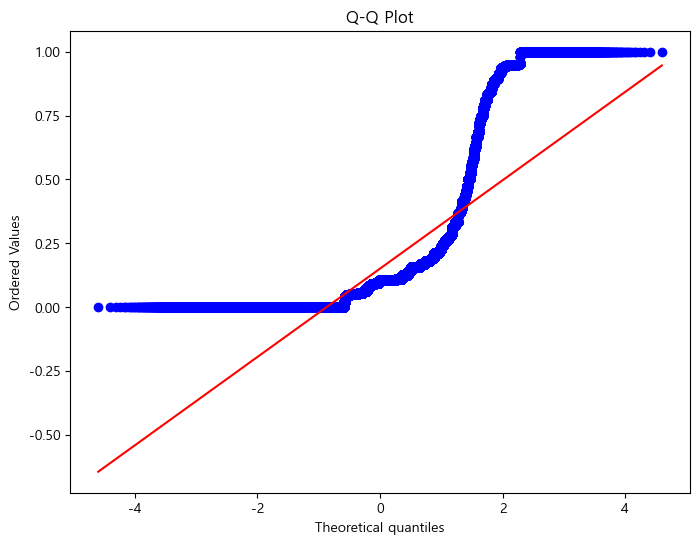

In [192]:
# 전체 분포 QQplot and 분포확인

# 히스토그램 그리기
sns.histplot(pre['chapter_progress_pct'], kde=True)
plt.show()

# QQ-Plot 뽑아보기

plt.figure(figsize=(8, 6))
stats.probplot(pre['chapter_progress_pct'], dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

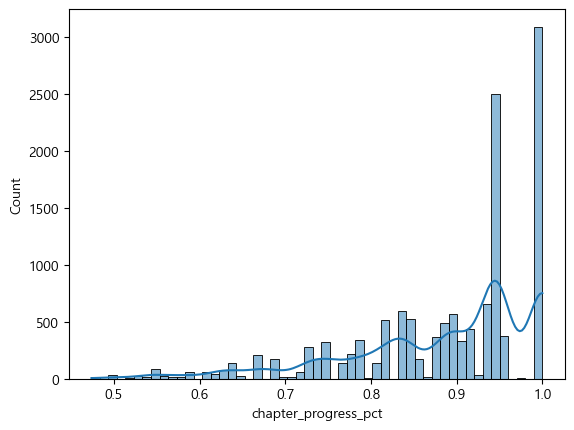

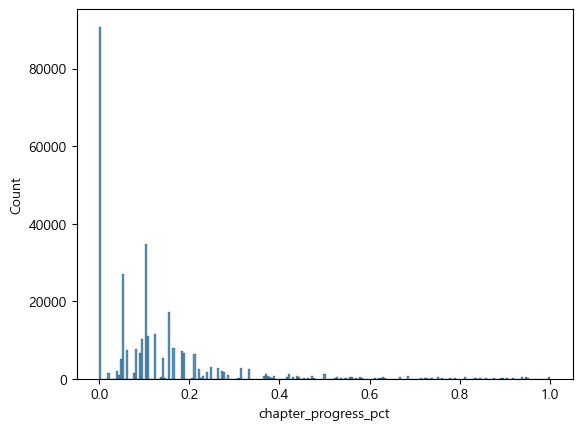

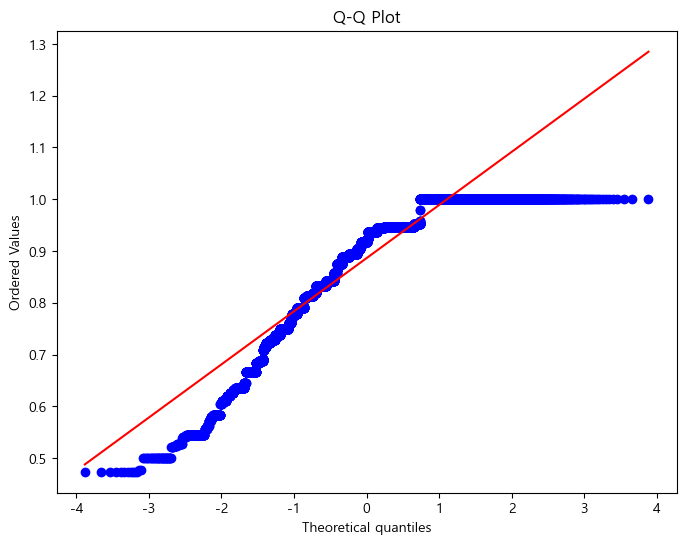

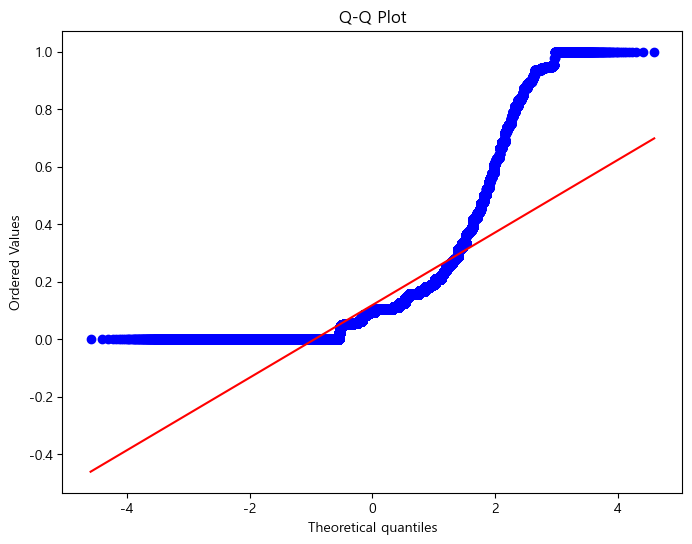

In [193]:
# QQplot and 분포확인

# 히스토그램 그리기
sns.histplot(cp_T, kde=True)
plt.show()

sns.histplot(cp_F, kde=False)
plt.show()

# QQ-Plot 뽑아보기

plt.figure(figsize=(8, 6))
stats.probplot(cp_T, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

plt.figure(figsize=(8, 6))
stats.probplot(cp_F, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [194]:
# 통계검정 (비모수 검정인 mannwhitneyU검정 수행)

stat_U, p_U = stats.mannwhitneyu(cp_T, cp_F, alternative='two-sided')
print(stat_U, p_U) # 당연히 p < 0.05

4143550441.0 0.0


In [195]:
rbc_le = rbc(le_T, le_F, stat_U)
print(rbc_le) # 0.9879505081682742

0.9879505081682742


## 수료를 한 그룹과 안한 그룹의 학습 참여 점수는 차이가 있을까?

<Axes: >

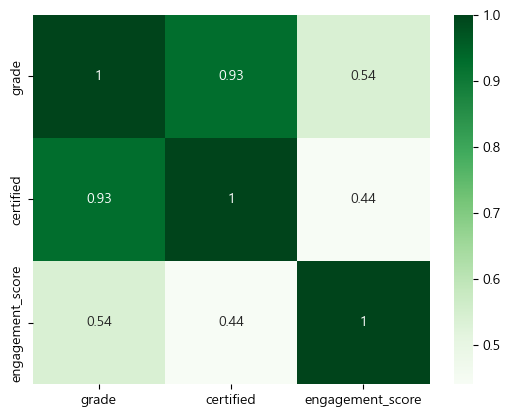

In [196]:
# 학습 참여 점수 통계검정 시작
# 성과 지표와의 상관관계
score_corr = pre[['grade', 'certified', 'engagement_score']].corr()
sns.heatmap(score_corr, cmap = 'Greens', annot=True)


In [197]:
# 수료 여부별 학습 몰입도 비교
# 데이터 분리

es_T = pre.loc[
    (pre['certified']==1),
    'engagement_score'
    ]

es_F = pre.loc[
    (pre['certified']==0,
    'engagement_score')
]

print(len(es_T))# 13426
print(len(es_F))# 310492


13426
310492


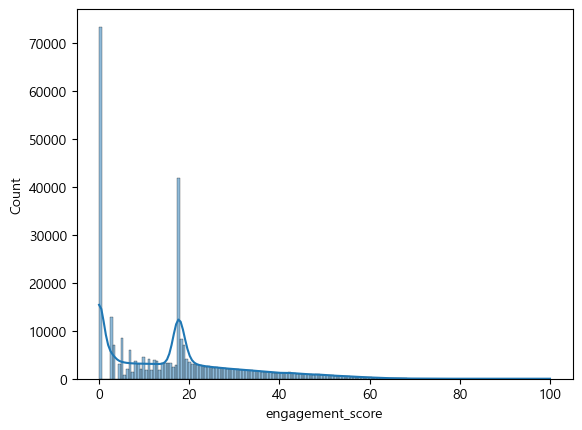

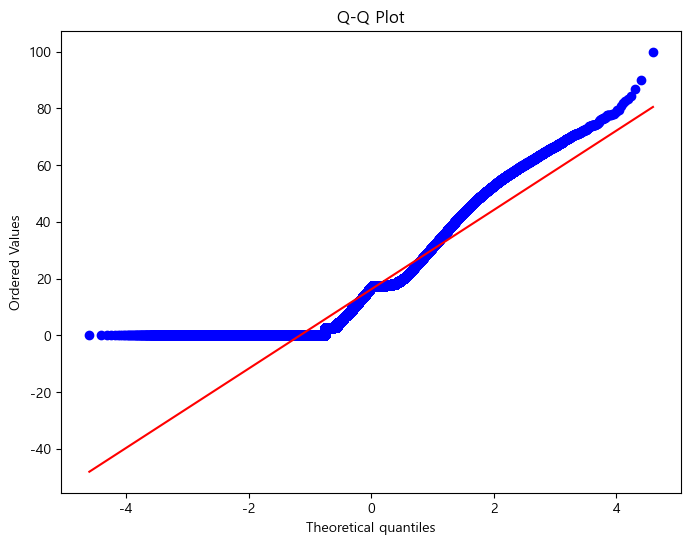

In [198]:
# 전체 분포 QQplot and 분포확인

# 히스토그램 그리기
sns.histplot(pre['engagement_score'], kde=True)
plt.show()

# QQ-Plot 뽑아보기

plt.figure(figsize=(8, 6))
stats.probplot(pre['engagement_score'], dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

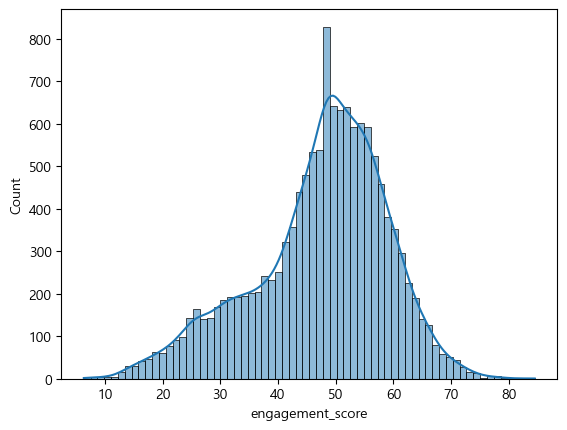

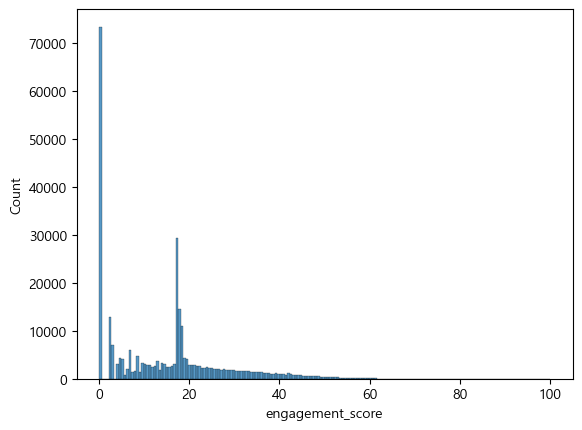

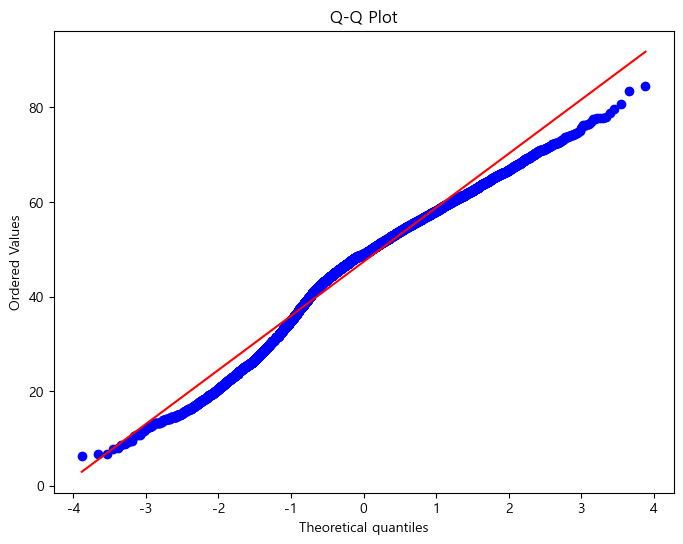

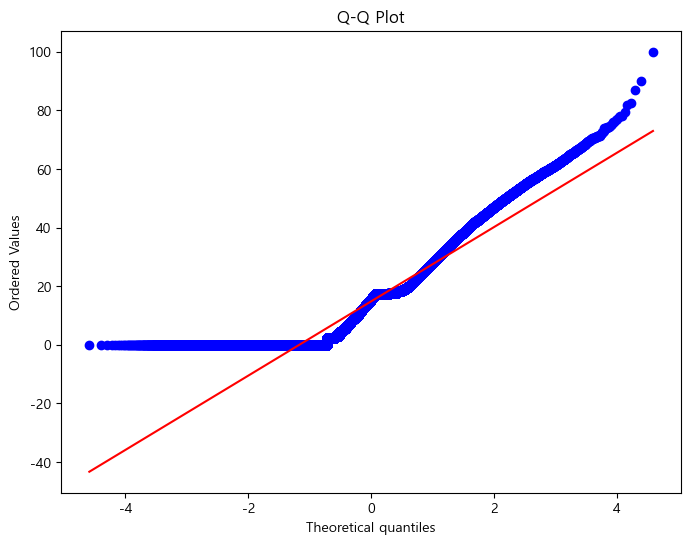

In [199]:
# QQplot and 분포확인

# 히스토그램 그리기
sns.histplot(es_T, kde=True)
plt.show()

sns.histplot(es_F, kde=False)
plt.show()

# QQ-Plot 뽑아보기

plt.figure(figsize=(8, 6))
stats.probplot(es_T, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

plt.figure(figsize=(8, 6))
stats.probplot(es_F, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [200]:
# 통계검정 (비모수 검정인 mannwhitneyU검정 수행)

stat_U, p_U = stats.mannwhitneyu(es_T, es_F, alternative='two-sided')
print(stat_U, p_U) # 당연히 p < 0.05

3974633642.0 0.0


In [201]:
rbc_le = rbc(es_T, es_F, stat_U)
print(rbc_le) # 0.9069093235147656

0.9069093235147656
